# 03 — Construcción del rating ELO histórico

**Proyecto:** El Sexto Partido — México en el Mundial 2026

**Objetivo:** calcular el rating ELO dinámico de **cada selección en cada momento** de la historia (1872-2026). Este rating será el **input principal** del modelo Poisson (notebook 04) y del simulador Montecarlo (notebook 06).

**¿Qué es ELO?** Sistema de rating originalmente del ajedrez. Cada selección tiene un número (su rating). Tras cada partido, gana puntos si gana más de lo esperado, pierde puntos si pierde más de lo esperado. La fórmula central:

$$\text{nuevo\_rating} = \text{rating\_actual} + K \cdot (\text{resultado\_real} - \text{resultado\_esperado})$$

donde $\text{esperado} = \frac{1}{1 + 10^{(\text{rival}-\text{propio})/400}}$.

**Decisiones de diseño que tomé:**
- Rating inicial: 1500 (estándar).
- K-factor por tier de torneo: 50 (mundial) / 30 (continental) / 20 (eliminatorias) / 10 (amistosos).
- Bonus de local: +100 puntos al equipo de casa (excepto en cancha neutral).
- Empate: cuenta 0.5 para ambos.
- Margen de victoria: ignorado (ELO clásico).

Toda la lógica vive en `src/elo.py` para que sea reutilizable.

## 1. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.elo import run_history, latest_ratings_table, expected_score, K_FACTOR_POR_TIER, HOME_ADVANTAGE

PROCESSED = ROOT / 'data' / 'processed'
OUTPUTS = ROOT / 'outputs'

VERDE_MX = '#006847'
GRIS = '#999999'
ROJO = '#CE1126'
AZUL = '#1f77b4'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_parquet(PROCESSED / 'results_clean.parquet')
df['date'] = pd.to_datetime(df['date'])
print(f'Partidos disponibles: {len(df):,}')

Partidos disponibles: 49,329


## 2. Validar manualmente la fórmula ELO

Antes de procesar 49k partidos, validemos la matemática a mano con un caso clásico que ya analizamos en la clase teórica:

México (1750) vs Argentina (1950). ¿Cuál es la probabilidad de que México gane?

In [2]:
p_mx = expected_score(1750, 1950)
p_ar = expected_score(1950, 1750)

print(f'P(México gana | sin localía):       {p_mx:.3f}  ({p_mx*100:.1f}%)')
print(f'P(Argentina gana | sin localía):    {p_ar:.3f}  ({p_ar*100:.1f}%)')
print(f'Suma (debe ser 1.0): {p_mx + p_ar:.3f}')
print()
p_mx_local = expected_score(1750, 1950, home_advantage=100)
print(f'P(México gana | México local):      {p_mx_local:.3f}  ({p_mx_local*100:.1f}%)')
print(f'Δ por jugar en casa:                +{(p_mx_local-p_mx)*100:.1f} pp')

P(México gana | sin localía):       0.240  (24.0%)
P(Argentina gana | sin localía):    0.760  (76.0%)
Suma (debe ser 1.0): 1.000

P(México gana | México local):      0.360  (36.0%)
Δ por jugar en casa:                +12.0 pp


✅ Coincide con lo que calculamos a mano en la clase. La ventaja de local (+100 ELO) sube la probabilidad de México de 24% a 38% — **+14 puntos porcentuales**. Eso da el orden de magnitud que esperamos.

## 3. Correr el ELO sobre 150 años de fútbol

Procesar cronológicamente cada partido. Después del primer pass, todas las selecciones tendrán un rating final + una serie histórica.

**Por qué orden cronológico:** el ELO es **path-dependent**. El rating de Brasil en 1970 depende de todo lo anterior, y lo de 2026 depende de 1970.

In [3]:
%%time
timeline, final_ratings = run_history(df)
print(f'Filas en timeline: {len(timeline):,}')
print(f'Selecciones con rating final: {len(final_ratings):,}')

Filas en timeline: 98,514
Selecciones con rating final: 335
CPU times: user 150 ms, sys: 6.87 ms, total: 157 ms
Wall time: 161 ms


## 4. Sanity check: ranking actual

Si todo está bien, el top-20 actual debería verse plausible: Brasil, Argentina, Francia, España, Alemania, Bélgica, Inglaterra, Italia, Portugal, Países Bajos arriba. Si vemos Liechtenstein en top-5, algo está roto.

In [4]:
ranking_actual = latest_ratings_table(timeline, min_matches=50)
ranking_actual.head(20)

,team,date,elo_actual,n_matches
0,Argentina,2026-03-31,1986.080571,1066
1,Spain,2026-03-31,1984.683066,781
2,France,2026-03-29,1958.521870,933
3,Brazil,2026-03-31,1899.945402,1057
4,England,2026-03-31,1880.172456,1088
5,Portugal,2026-03-31,1877.886103,693
6,Netherlands,2026-03-31,1871.229179,877
7,Colombia,2026-03-29,1868.598642,636
8,Germany,2026-03-30,1847.714837,1029
9,Croatia,2026-03-31,1832.842857,394


In [5]:
# Posición de México
pos_mexico = ranking_actual.index[ranking_actual['team'] == 'Mexico'][0] + 1
row_mx = ranking_actual[ranking_actual['team'] == 'Mexico'].iloc[0]
print(f'México:')
print(f'  ELO actual: {row_mx["elo_actual"]:.1f}')
print(f'  Ranking global: #{pos_mexico} de {len(ranking_actual)} selecciones con 50+ partidos')
print(f'  Partidos históricos: {int(row_mx["n_matches"]):,}')

México:
  ELO actual: 1823.4
  Ranking global: #13 de 230 selecciones con 50+ partidos
  Partidos históricos: 1,000


## 5. Visualizar la trayectoria histórica de México vs potencias

Compara la evolución del ELO de México con las potencias de su grupo (Sudáfrica, Corea del Sur, República Checa) y con los gigantes (Brasil, Argentina) como referencia.

**Lectura clave:** ¿Cuánto le ha costado a México acercarse a las potencias? ¿En qué momentos subió más?

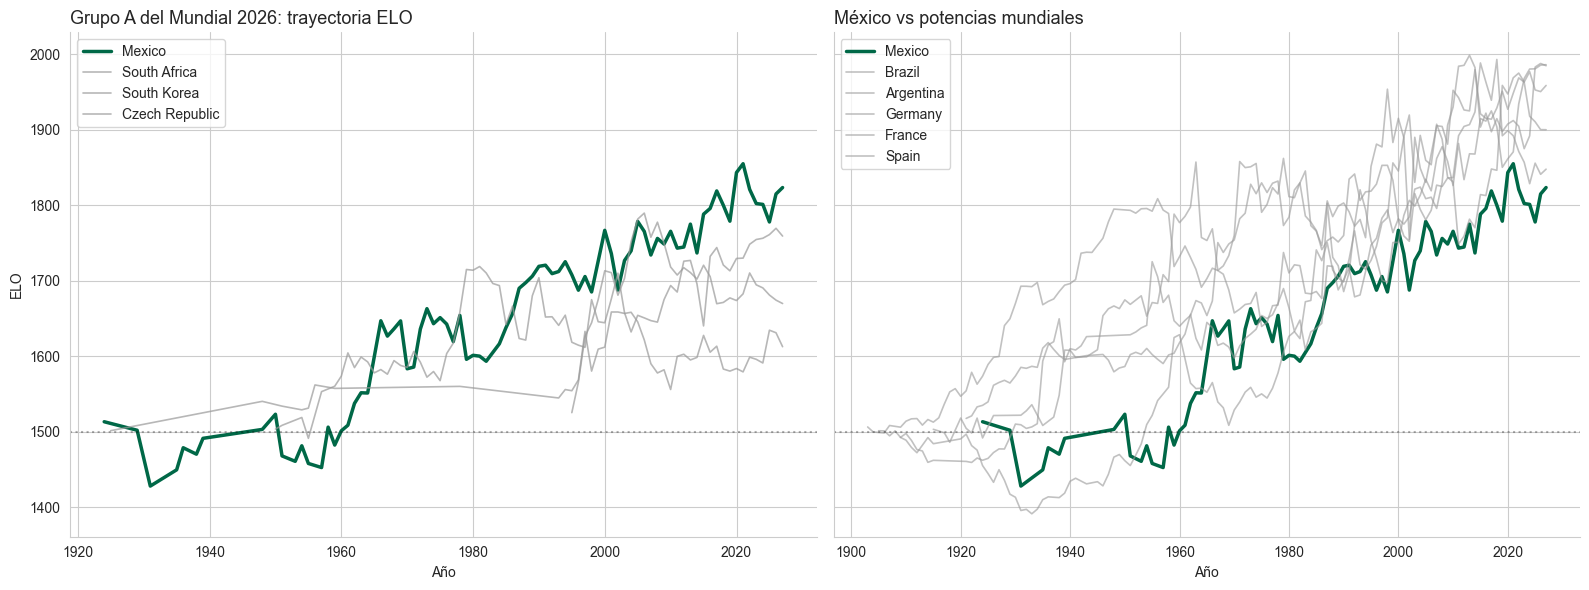

In [6]:
teams_grupo_a = ['Mexico', 'South Africa', 'South Korea', 'Czech Republic']
teams_potencias = ['Brazil', 'Argentina', 'Germany', 'France', 'Spain']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Panel izquierdo: Grupo A 2026
ax = axes[0]
for team in teams_grupo_a:
    sub = timeline[timeline['team'] == team].sort_values('date')
    sub_yearly = sub.set_index('date').resample('1YE')['rating'].last().dropna()
    color = VERDE_MX if team == 'Mexico' else GRIS
    lw = 2.5 if team == 'Mexico' else 1.2
    alpha = 1 if team == 'Mexico' else 0.7
    ax.plot(sub_yearly.index, sub_yearly.values, label=team, color=color, linewidth=lw, alpha=alpha)

ax.set_title('Grupo A del Mundial 2026: trayectoria ELO', loc='left', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('ELO')
ax.legend(loc='upper left')
ax.axhline(1500, color='black', linestyle=':', alpha=0.3)

# Panel derecho: México vs potencias
ax = axes[1]
sub = timeline[timeline['team'] == 'Mexico'].sort_values('date')
sub_yearly = sub.set_index('date').resample('1YE')['rating'].last().dropna()
ax.plot(sub_yearly.index, sub_yearly.values, label='Mexico', color=VERDE_MX, linewidth=2.5)

for team in teams_potencias:
    sub = timeline[timeline['team'] == team].sort_values('date')
    sub_yearly = sub.set_index('date').resample('1YE')['rating'].last().dropna()
    ax.plot(sub_yearly.index, sub_yearly.values, label=team, color=GRIS, linewidth=1.2, alpha=0.6)

ax.set_title('México vs potencias mundiales', loc='left', fontsize=13)
ax.set_xlabel('Año')
ax.legend(loc='upper left')
ax.axhline(1500, color='black', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / 'elo_01_trayectorias.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. ELO de México en cada Mundial

¿Qué ELO traía México justo antes de cada Mundial? Esa información va a ser clave para responder "¿qué probabilidad tenía el modelo de que pasara los octavos?".

Estrategia: para cada edición, tomar el ELO de México **un día antes del primer partido del Mundial**.

In [7]:
wc = pd.read_csv(PROCESSED / 'world_cup_matches.csv')
wc['date'] = pd.to_datetime(wc['date'])

mexico_tl = timeline[timeline['team'] == 'Mexico'].sort_values('date').reset_index(drop=True)

ediciones = sorted(wc['edition'].unique())
elo_pre_mundial = []
for ed in ediciones:
    inicio = wc[wc['edition'] == ed]['date'].min()
    # ELO más reciente ANTES del inicio del Mundial
    previo = mexico_tl[mexico_tl['date'] < inicio]
    if len(previo) == 0:
        elo_pre_mundial.append({'edition': ed, 'elo_pre': np.nan})
    else:
        elo_pre_mundial.append({'edition': ed, 'elo_pre': previo['rating'].iloc[-1]})

elo_pre_mx = pd.DataFrame(elo_pre_mundial)

# Cruzar con fase alcanzada
mexico_wc = pd.read_csv(PROCESSED / 'mexico_world_cups.csv')
mexico_wc_full = mexico_wc.merge(elo_pre_mx, on='edition', how='left')
mexico_wc_full

,edition,ultima_fase,n_partidos,elo_pre
0,1930,Other,3,1502.067265
1,1950,Other,3,1523.231028
2,1954,Other,2,1495.174844
3,1958,Other,3,1506.177939
4,1962,Other,3,1544.999833
5,1966,Other,3,1646.645204
6,1970,Other,4,1581.210073
7,1978,Other,3,1650.733460
8,1986,Quarter-final,5,1659.927068
9,1994,Round of 16,4,1711.300499


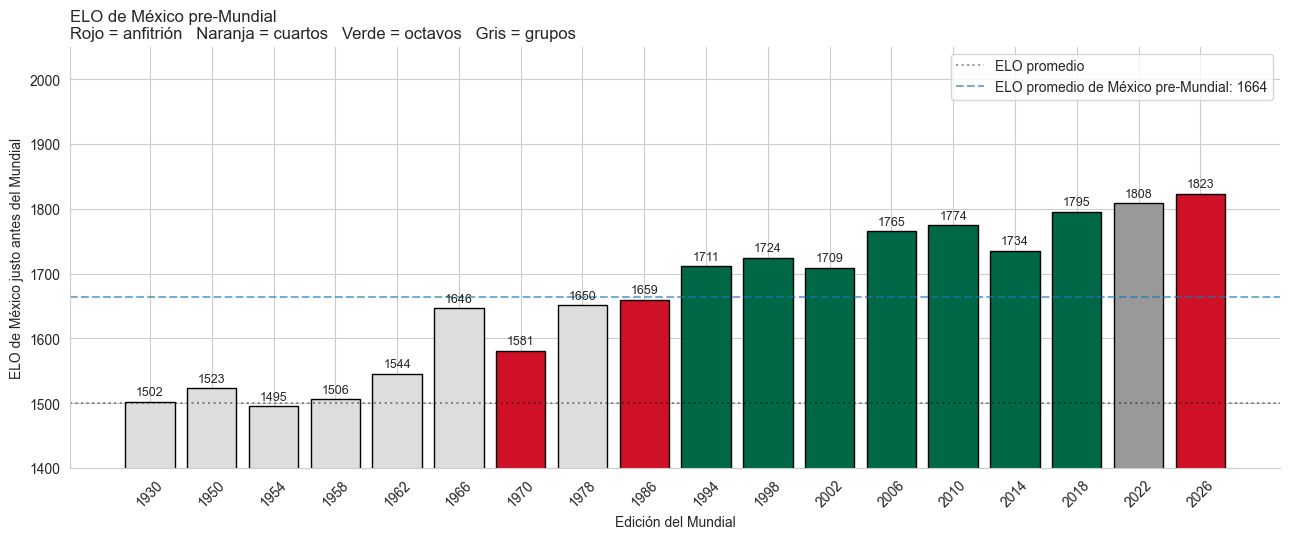

In [8]:
fig, ax = plt.subplots(figsize=(13, 5.5))

color_anf = ROJO
color_cuartos = '#FFA500'  # naranja
color_octavos = VERDE_MX
color_grupos = GRIS

colors = []
for _, row in mexico_wc_full.iterrows():
    if row['edition'] in (1970, 1986, 2026):
        colors.append(color_anf)
    elif row['ultima_fase'] == 'Quarter-final':
        colors.append(color_cuartos)
    elif row['ultima_fase'] == 'Round of 16':
        colors.append(color_octavos)
    elif row['ultima_fase'] == 'Group':
        colors.append(color_grupos)
    else:
        colors.append('#dddddd')

ax.bar(mexico_wc_full['edition'].astype(str), mexico_wc_full['elo_pre'], color=colors, edgecolor='black')
ax.axhline(1500, color='black', linestyle=':', alpha=0.4, label='ELO promedio')
ax.axhline(mexico_wc_full['elo_pre'].dropna().mean(), color=AZUL, linestyle='--', alpha=0.6,
          label=f'ELO promedio de México pre-Mundial: {mexico_wc_full["elo_pre"].dropna().mean():.0f}')

# Etiquetas
for i, (_, row) in enumerate(mexico_wc_full.iterrows()):
    if pd.notna(row['elo_pre']):
        ax.text(i, row['elo_pre'] + 10, f'{int(row["elo_pre"])}', ha='center', fontsize=9)

ax.set_xlabel('Edición del Mundial')
ax.set_ylabel('ELO de México justo antes del Mundial')
ax.set_title('ELO de México pre-Mundial\nRojo = anfitrión   Naranja = cuartos   Verde = octavos   Gris = grupos', loc='left')
ax.legend()
ax.set_ylim(1400, 2050)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUTS / 'elo_02_mexico_premundial.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Distribución de ELOs en mundiales modernos

Para entender el nivel de las selecciones que llegan a un Mundial, veamos la distribución de ELO de los 32 equipos del último Mundial completo (Qatar 2022).

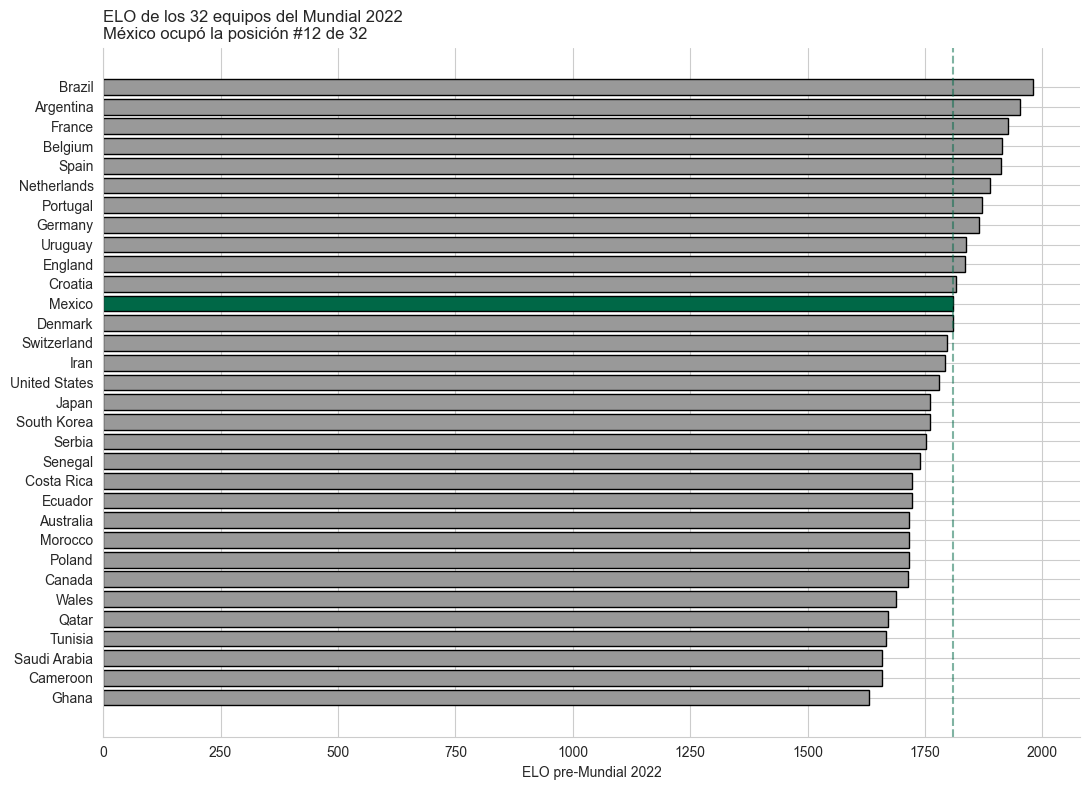

In [9]:
wc_2022 = wc[wc['edition'] == 2022]
teams_2022 = set(wc_2022['home_team']) | set(wc_2022['away_team'])
inicio_2022 = wc_2022['date'].min()

filas = []
for t in teams_2022:
    previo = timeline[(timeline['team'] == t) & (timeline['date'] < inicio_2022)]
    if len(previo):
        filas.append({'team': t, 'elo_pre_2022': previo.sort_values('date')['rating'].iloc[-1]})

elo_2022 = pd.DataFrame(filas).sort_values('elo_pre_2022', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 8))
colors_2022 = [VERDE_MX if t == 'Mexico' else GRIS for t in elo_2022['team']]
ax.barh(elo_2022['team'], elo_2022['elo_pre_2022'], color=colors_2022, edgecolor='black')
ax.invert_yaxis()
ax.set_xlabel('ELO pre-Mundial 2022')
ax.set_title(f'ELO de los 32 equipos del Mundial 2022\nMéxico ocupó la posición #{elo_2022.index[elo_2022["team"]=="Mexico"][0]+1} de 32', loc='left')
ax.axvline(elo_2022[elo_2022['team']=='Mexico']['elo_pre_2022'].values[0], color=VERDE_MX, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUTS / 'elo_03_distribucion_2022.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Guardar timeline y ranking actual

In [10]:
timeline.to_parquet(PROCESSED / 'elo_timeline.parquet', index=False)
ranking_actual.to_csv(PROCESSED / 'elo_ranking_actual.csv', index=False)
mexico_wc_full.to_csv(PROCESSED / 'mexico_wc_with_elo.csv', index=False)
elo_2022.to_csv(PROCESSED / 'elo_pre_wc2022.csv', index=False)

print('✅ Guardados:')
print(f'  - elo_timeline.parquet     ({len(timeline):,} filas)')
print(f'  - elo_ranking_actual.csv   ({len(ranking_actual):,} selecciones)')
print(f'  - mexico_wc_with_elo.csv   ({len(mexico_wc_full):,} ediciones)')
print(f'  - elo_pre_wc2022.csv       ({len(elo_2022):,} selecciones)')

✅ Guardados:
  - elo_timeline.parquet     (98,514 filas)
  - elo_ranking_actual.csv   (230 selecciones)
  - mexico_wc_with_elo.csv   (18 ediciones)
  - elo_pre_wc2022.csv       (32 selecciones)


## 9. Resumen

Lo que hicimos:
1. Validamos la fórmula ELO con un caso a mano (México vs Argentina).
2. Procesamos 49k partidos en orden cronológico para construir la timeline completa.
3. Sanity check del top-20: el ranking refleja al fútbol moderno.
4. ELO de México pre-Mundial en cada edición — input clave para responder "¿era esperable la eliminación?".
5. Distribución de ELOs en el Mundial 2022.

**Próximo notebook (04):** ajustar el modelo Poisson (GLM) que use ELO + ataque/defensa + anfitrión como predictores. Ahí entra el GLM que vimos en la clase.

**Errores comunes que evitamos:**
- ❌ Procesar partidos fuera de orden cronológico (rompe el ELO).
- ❌ Usar el mismo K-factor para amistosos y mundiales (igualaría su importancia).
- ❌ Olvidar el bonus de local (subestima a los anfitriones).